In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import scipy.linalg
import math

import torch

def power_of_matrix(A, n):
    """
    Calculate A^n with A matrix
    """
    if n == 0:
        res = np.eye(A.shape[0])
        return res
    res = A
    while n > 1:
        res = res @ A
        n -= 1
    return res

def solution(U):
    # find the eigenvalues and eigenvector of U(transpose).U
    e_vals, e_vecs = np.linalg.eig(np.dot(U.T, U))  
    # extract the eigenvector (column) associated with the minimum eigenvalue
    return e_vecs[:, np.argmin(e_vals)]

In [1]:
from lib.ECP import ErgodicCP_logisticfill

lambda_buy = 5
lambda_sell = 5

q_upper = 5
q_lower = -5

phi = 0.01        # inventory risk penalty
a = -2            # logistic parameters
b = 10

alpha = 0.1       # terminal inventory penalty

x = 0             # initial cash
S = 100           # midprice

solver = ErgodicCP_logisticfill(
    lambda_buy,
    lambda_sell,
    q_upper,
    q_lower,
    phi,
    a,
    b,
    alpha,
    x,
    S
)

T = 20


Inventory states: [-5 -4 -3 -2 -1  0  1  2  3  4  5]
Value function shape: (11, 200)
T:210
Difference:45.556325804695696
T:310
Difference:2.5088275507477835
T:410
Difference:0.8902291309105039
T:510
Difference:0.45597101827123376
T:610
Difference:0.2771588542432988
T:710
Difference:0.18628709875369276
T:810
Difference:0.13381185966814546
T:910
Difference:0.10077189431798605
T:1010
Difference:0.0786242252371101
T:1110
Difference:0.06305507172481095
T:1210
Difference:0.05169379754016046
T:1310
Difference:0.043149368194679294
T:1410
Difference:0.0365616783939649
T:1510
Difference:0.03137562472106209
T:1610
Difference:0.02721991283747771
Time horizons tested: [10, 110, 210, 310, 410, 510, 610, 710, 810, 910, 1010, 1110, 1210, 1310, 1410, 1510, 1610]
Ergodic estimates: [array([-49.17513634, -39.15407539, -29.1390929 , -19.12920389,
        -9.12297577,   0.87867442,  10.87702423,  20.87079611,
        30.8609071 ,  40.84592461,  50.82486366]), array([-3.82237123, -2.91160076, -2.0009019 , -

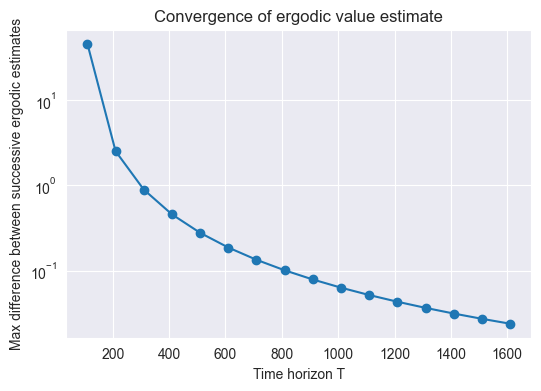

In [4]:
t, h, q_grid = solver.solve_HJB(T)

print("Inventory states:", q_grid)
print("Value function shape:", h.shape)

T_eval, ergodic_values, q_grid = solver.Ergodic_limit()

import numpy as np
import matplotlib.pyplot as plt

print("Time horizons tested:", T_eval)
print("Ergodic estimates:", ergodic_values)

ergodic_values = np.array(ergodic_values)

# compute successive differences
diff = np.max(np.abs(ergodic_values[1:] - ergodic_values[:-1]), axis=1)

plt.figure(figsize=(6,4))
plt.plot(T_eval[1:], diff, marker='o')
plt.yscale("log")

plt.xlabel("Time horizon T")
plt.ylabel("Max difference between successive ergodic estimates")
plt.title("Convergence of ergodic value estimate")
plt.grid(True)

plt.show()


In [5]:
# Value function for classical market making problem, calculate v(., T) / T
Time = np.arange(50, 950, 10)

dt = 1
# Posted LO is filled with probability of e^(-kappa*depth)
kappa_sell , kappa_buy = 10**1 , 10**1
assert kappa_buy == kappa_sell
kappa = kappa_sell
# Arrival rate of selling MOs from other participants in market
lambda_sell = 1
# Arrival rate of buying MOs from other participants in market
lambda_buy = 1
# Inventory boundary
q_upper = 30
q_lower = -30
# Risk aversion parameters
alpha = 0
phi = 1*10**-5

sigma = 0.05


X0 = 0
S0 = 10

# Let A denote a square matrix
A = np.zeros([q_upper-q_lower+1, q_upper-q_lower+1])
z = np.zeros(q_upper-q_lower+1)
# w = np.zeros([length, q_upper - q_lower + 1])
# optimal_depth_bid = np.zeros([length, q_upper - q_lower])
# optimal_depth_ask = np.zeros([length, q_upper - q_lower])

# Notice we assume kappa_buy = kappa_sell in the model
# i denotes the column number
for i in range(q_upper-q_lower+1):
    # j denotes the row number
    for j in range(q_upper-q_lower+1):
        if j == i:
            # q = q_upper - j
            A[j,i] = - phi*kappa*(q_upper-j)**2
        elif j == i-1:
            A[j,i] = lambda_buy*np.e**(-1)
        elif j == i+1:
            A[j,i] = lambda_sell*np.e**(-1)

for i in range(q_upper-q_lower+1):
    # q = q_upper - i
    z[i] = np.exp(-alpha*kappa*(q_upper-i)**2)

In [3]:
Q_initial = [-15, -10, -5, 0, 4, 8, 12]

value_over_t = []

for Q0 in Q_initial:
    value_over_t_q0 = []
    for T in Time: 
        t =np.arange(0, T+dt, dt)
        length = len(t)

        h = np.zeros([length , q_upper-q_lower+1])
        delta_buy = np.zeros([length , q_upper-q_lower])
        delta_sell = np.zeros([length , q_upper-q_lower])
            
        for i in range(length):
            h[i] = np.log(np.dot(expm(A*(T-i*dt)),z))/kappa

        for j in range(q_upper-q_lower):
            # q = q_upper - j
            delta_sell[:,j] = 1/kappa + h[:,j] - h[:,j+1]

        for j in range(q_upper-q_lower):
            # q = q_upper -1 - j
            delta_buy[:,j] = 1/kappa + h[:,j+1] - h[:,j]

        theo_value_function = h[0,int(q_upper - Q0)]
        value_over_t_q0.append(theo_value_function / T)
    value_over_t.append(value_over_t_q0)

In [4]:
# Let see whether A is diagonalizable
import scipy.linalg

evalues, evectors = scipy.linalg.eig(A)
Tau = np.zeros((len(evalues), len(evalues)))

for i in range(len(evalues)):
    Tau[i, i] = np.real(evalues[i])

gamma = np.real(max(evalues)) / kappa_sell

<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_36676/1048819872.py:3: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(Time, [gamma for i in Time], '--', label='$\gamma = \lambda_{max} / \kappa$')


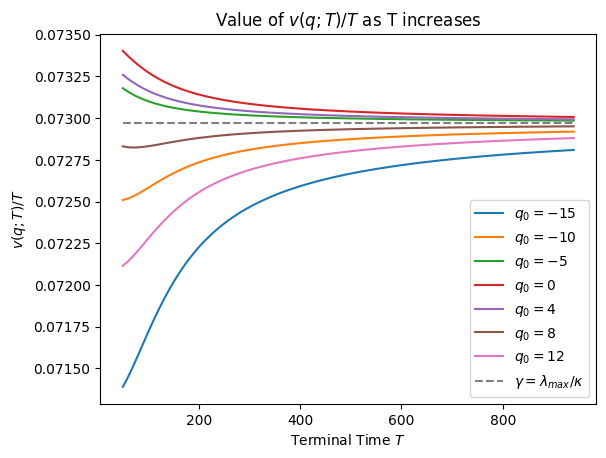

In [5]:
for i in range(len(Q_initial)):
    plt.plot(Time, value_over_t[i], label=f"$q_0={Q_initial[i]}$")
plt.plot(Time, [gamma for i in Time], '--', label='$\gamma = \lambda_{max} / \kappa$')
plt.xlabel("Terminal Time $T$")
plt.ylabel("$v(q; T) / T$")
plt.title("Value of $v(q; T) / T$ as T increases")
plt.legend()
plt.show()

## Numerically solve the ergodic control problem

In [6]:
# Let C denote a square matrix
C = np.zeros([q_upper-q_lower+1, q_upper-q_lower+1])

# Notice we assume kappa_buy = kappa_sell in the model
# i denotes the column number
for i in range(q_upper-q_lower+1):
    # j denotes the row number
    for j in range(q_upper-q_lower+1):
        if j == i:
            # q = q_upper - j
            C[j,i] = - kappa*(phi*(q_upper-j)**2 + gamma)
        elif j == i-1:
            C[j,i] = lambda_buy*np.e**(-1)
        elif j == i+1:
            C[j,i] = lambda_sell*np.e**(-1)

In [7]:
print("The shape of coefficient matrix is:", C.shape)
print("The rank of coefficient matrix is:", np.linalg.matrix_rank(C))
print("Therefore, there will be non-trivial solution of v(q)")
print("Since the rank of coefficient matrix is n-1, so the solution must be unique up to a constant")

The shape of coefficient matrix is: (61, 61)
The rank of coefficient matrix is: 60
Therefore, there will be non-trivial solution of v(q)
Since the rank of coefficient matrix is n-1, so the solution must be unique up to a constant


<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_36676/3710000789.py:16: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Solutions $\hat{v}(q)$ to Ergodic HJB Equation")


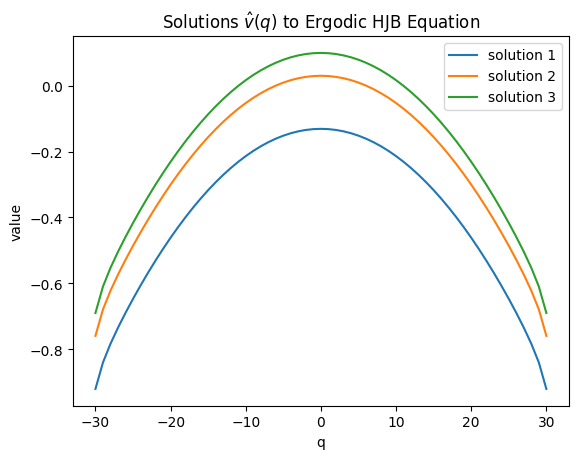

In [8]:
Q = torch.arange(q_lower,q_upper+1,1).type(torch.float)
Q = Q.reshape(-1,1)
Q = Q.detach().cpu().numpy()

solu1 = -1 * solution(C)
solu2 = -5 * solution(C)
solu3 = -10 * solution(C)

plt.plot(Q.flatten(), np.log(solu1)/kappa, label='solution 1')
plt.plot(Q.flatten(), np.log(solu2)/kappa, label='solution 2')
plt.plot(Q.flatten(), np.log(solu3)/kappa, label='solution 3')

plt.legend()
plt.xlabel("q")
plt.ylabel("value")
plt.title("Solutions $\hat{v}(q)$ to Ergodic HJB Equation")
plt.show()

In [9]:
solu2 = np.log(solu2)/kappa

delta_buy = np.zeros(q_upper - q_lower)
delta_sell = np.zeros(q_upper - q_lower)

for i in range(1, q_upper-q_lower+1):
    delta_sell[i-1] = 1/kappa_buy - solu2[i-1] + solu2[i]
for i in range(q_upper-q_lower):
    delta_buy[i] = 1/kappa_buy + solu2[i] - solu2[i+1]

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_36676/955668474.py:4: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('Offset(depth) $\delta$')
/tmp/ipykernel_36676/955668474.py:5: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Optimal Strategy $\psi^{\pm}(q)$ for Ergodic Control Problem")


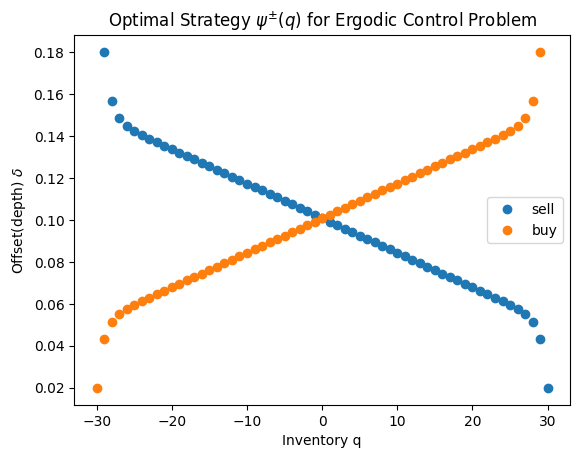

In [10]:
plt.plot(Q.flatten()[1:], delta_sell, 'o',label='sell')
plt.plot(Q.flatten()[:-1], delta_buy, 'o',label='buy')
plt.xlabel("Inventory q")
plt.ylabel('Offset(depth) $\delta$')
plt.title("Optimal Strategy $\psi^{\pm}(q)$ for Ergodic Control Problem")
plt.legend()
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_36676/1022313784.py:6: SyntaxWarning: invalid escape sequence '\g'
  axes[0].plot(Time, [gamma for _ in Time], '--', label='$\gamma = \lambda_{max} / \kappa$')
/tmp/ipykernel_36676/1022313784.py:26: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_title("Solutions $\hat{v}(q)$ to Ergodic HJB Equation")
/tmp/ipykernel_36676/1022313784.py:33: SyntaxWarning: invalid escape sequence '\d'
  axes[2].set_ylabel("Offset(depth) $\delta$")
/tmp/ipykernel_36676/1022313784.py:34: SyntaxWarning: invalid escape sequence '\p'
  axes[2].set_title("Optimal Strategy $\psi^{\pm}(q)$

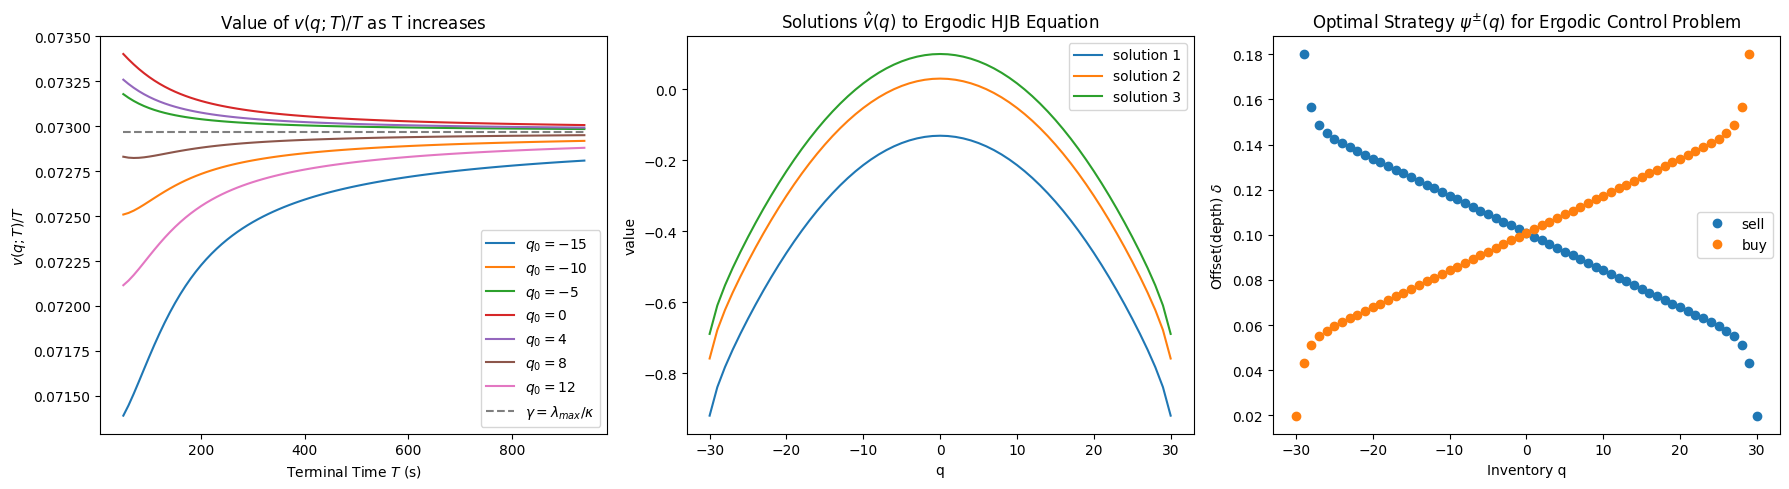

: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns

# --- Plot 1: Normalised Value over Time ---
for i in range(len(Q_initial)):
    axes[0].plot(Time, value_over_t[i], label=f"$q_0={Q_initial[i]}$")
axes[0].plot(Time, [gamma for _ in Time], '--', label='$\gamma = \lambda_{max} / \kappa$')
axes[0].set_xlabel("Terminal Time $T$ (s)")
axes[0].set_ylabel("$v(q; T) / T$")
axes[0].set_title("Value of $v(q; T) / T$ as T increases")
axes[0].legend()

# --- Plot 2: Solutions to Ergodic HJB Equation ---
Q = torch.arange(q_lower, q_upper + 1, 1).type(torch.float)
Q = Q.reshape(-1, 1)
Q = Q.detach().cpu().numpy()

solu1 = -1 * solution(C)
solu2 = -5 * solution(C)
solu3 = -10 * solution(C)

axes[1].plot(Q.flatten(), np.log(solu1)/kappa, label='solution 1')
axes[1].plot(Q.flatten(), np.log(solu2)/kappa, label='solution 2')
axes[1].plot(Q.flatten(), np.log(solu3)/kappa, label='solution 3')
axes[1].set_xlabel("q")
axes[1].set_ylabel("value")
axes[1].set_title("Solutions $\hat{v}(q)$ to Ergodic HJB Equation")
axes[1].legend()

# --- Plot 3: Optimal Strategy ---
axes[2].plot(Q.flatten()[1:], delta_sell, 'o', label='sell')
axes[2].plot(Q.flatten()[:-1], delta_buy, 'o', label='buy')
axes[2].set_xlabel("Inventory q")
axes[2].set_ylabel("Offset(depth) $\delta$")
axes[2].set_title("Optimal Strategy $\psi^{\pm}(q)$ for Ergodic Control Problem")
axes[2].legend()

plt.tight_layout()


#plt.savefig("/Users/galen/Desktop/ergodic_sim.pdf", format='pdf', bbox_inches='tight')
plt.show()
plt.close()


## Ergodicity

In [6]:
T = 1000
ts_size = 0.1
ts = np.arange(0, T+ts_size, ts_size)

Cash = []
Inventory = []
Midprice = []

length = len(ts)

for _ in range(5000):
    a = 0.0
    b = 0.5
    X = np.zeros(length)
    Q = np.zeros(length)
    S = np.zeros(length)
    dW = np.sqrt(dt)*np.random.randn(length-1)
    X[0] = 0
    Q[0] = 0
    S[0] = S0

    for i in range(length-1):
        S[i+1] = S[i] + sigma * dW[i]
        # current position
        q = int(Q[i])

        q_clipped = np.clip(int(Q[i]), q_lower, q_upper)
        delta_sell_current = 1e20 if q_clipped <= q_lower else delta_sell[q_upper + q_clipped - 1]
        delta_buy_current  = 1e20 if q_clipped >= q_upper else delta_buy[q_upper + q_clipped - 1]

        dN_sell = np.random.poisson(lambda_buy / (1 + np.exp(a + b*delta_sell_current)) * ts_size)
        dN_buy  = np.random.poisson(lambda_sell / (1 + np.exp(a + b*delta_buy_current)) * ts_size)
        # Cash process
        X[i+1] = X[i] + (S[i]+delta_sell_current)*dN_sell - (S[i]-delta_buy_current)*dN_buy
        # Inventory process
        Q[i+1] = Q[i] + dN_buy - dN_sell

    # calculate value function
    Cash.append(X)
    Inventory.append(Q)
    Midprice.append(S)

Cash = np.array(Cash)
inv = np.array(Inventory)
Midprice = np.array(Midprice)

mtm = Cash + inv * Midprice

NameError: name 'delta_sell' is not defined

In [ ]:
fig, ax = plt.subplots(2,3, figsize=(17,8))

ax[0,0].plot(ts, np.mean(inv, axis=0))
ax[0,0].set_xlabel("t(s)")
ax[0,0].set_ylabel("$E[Q_t]$")

ax[1,0].plot(ts, np.mean(inv**2, axis=0)**0.5)
ax[1,0].set_xlabel("t(s)")
ax[1,0].set_ylabel("$E[Q_t^2]^{1/2}$")

a = np.mean(inv**3, axis=0)
ax[0,1].plot(ts, np.sign(a) * (np.abs(a)) ** (1 / 3))
ax[0,1].set_xlabel("t(s)")
ax[0,1].set_ylabel("$E[Q_t^3]^{1/3}$")

ax[1,1].plot(ts, np.mean(inv**4, axis=0)**(1/4))
ax[1,1].set_xlabel("t(s)")
ax[1,1].set_ylabel("$E[Q_t^4]^{1/4}$")

a =  np.mean(inv**5, axis=0)
ax[0,2].plot(ts, np.sign(a) * (np.abs(a)) ** (1 / 5))
ax[0,2].set_xlabel("t(s)")
ax[0,2].set_ylabel("$E[Q_t^5]^{1/5}$")

ax[1,2].plot(ts, np.mean(inv**6, axis=0)**(1/6))
ax[1,2].set_xlabel("t(s)")
ax[1,2].set_ylabel("$E[Q_t^6]^{1/6}$")

fig.suptitle('$\mathbb{E}[Q_t^p]^{1/p}$ over time starting with $Q_0 = 0$', fontsize=15)

plt.show()

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_26813/2234475774.py:29: SyntaxWarning: invalid escape sequence '\m'
  fig.suptitle('$\mathbb{E}[Q_t^p]^{1/p}$ over time starting with $Q_0 = 0$', fontsize=15)


In [ ]:
a_log = 0
b_log = 0.5

Q = np.zeros([q_upper-q_lower+1, q_upper-q_lower+1])

for i in range(1, q_upper-q_lower):
    for j in range(q_upper-q_lower+1):
        if j == i:
            Q[i,j] = - lambda_buy / (1 + np.exp(a_log + b_log*delta_sell[q_upper - q_lower - 1 - i])) \
                     - lambda_sell / (1 + np.exp(a_log + b_log*delta_buy[q_upper - q_lower - i]))
        elif j == i+1:
            Q[i,j] = lambda_buy / (1 + np.exp(a_log + b_log*delta_sell[q_upper - q_lower - 1 - i]))
        elif j == i-1:
            Q[i,j] = lambda_sell / (1 + np.exp(a_log + b_log*delta_buy[q_upper - q_lower - i]))

Q[0,0] = - lambda_buy / (1 + np.exp(a_log + b_log*delta_sell[q_upper - q_lower - 1]))
Q[0,1] = lambda_buy / (1 + np.exp(a_log + b_log*delta_sell[q_upper - q_lower - 1]))
Q[q_upper - q_lower, q_upper - q_lower] = - lambda_sell / (1 + np.exp(a_log + b_log*delta_buy[0]))
Q[q_upper - q_lower, q_upper - q_lower - 1] = lambda_sell / (1 + np.exp(a_log + b_log*delta_buy[0]))

In [ ]:
def compute_stationary_distribution(Q):
    n = Q.shape[0]
    # Transpose the matrix Q
    Q_T = Q.T
    # Replace the last row with ones to enforce the normalization condition
    A = Q_T.copy()
    A[-1, :] = 1
    # Create the right-hand side vector with the last element as 1
    b = np.zeros(n)
    b[-1] = 1
    # Solve the linear system
    pi = np.linalg.solve(A, b)
    return pi

# calculate the stationary distribution
pi = compute_stationary_distribution(Q)

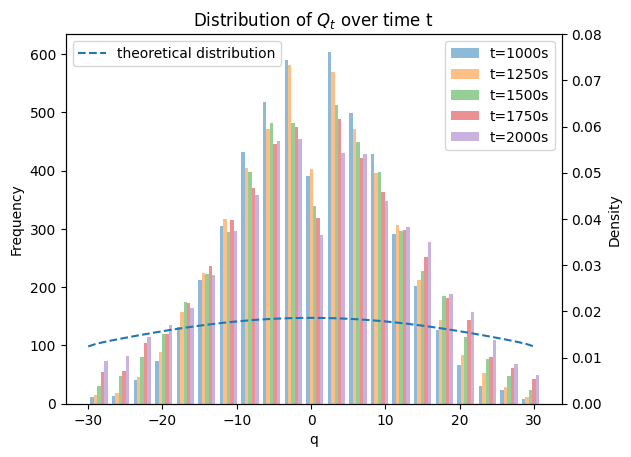

In [ ]:
fig, ax = plt.subplots()

ax.hist([inv[:, 1050], inv[:, 1200], inv[:, 1500],inv[:, 1750], inv[:, 2000]],bins=21,
          alpha=0.5,label=['t=1000s','t=1250s','t=1500s','t=1750s','t=2000s'])
ax.legend()
ax.set_xlabel("q")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of $Q_t$ over time t")

ax2=ax.twinx()
ax2.plot(np.arange(q_lower,q_upper+1,1), pi, '--', label='theoretical distribution')
ax2.legend(loc=2)
ax2.set_ylim(0, 0.08)
ax2.set_ylabel('Density')
plt.show()

In [5]:
from lib.ECP import ErgodicCP
import numpy as np 
import matplotlib.pyplot as plt

a_log = 0
b_log = 0.5

def transition_m(
    kappa, 
    q_upper = 10,
    q_lower = -10,
    lambda_buy = 1,
    lambda_sell = 1,
    kappa_star = 10, 
    phi = 1e-5, 
):
    
    P = np.zeros([q_upper-q_lower+1, q_upper-q_lower+1])
    
    control = ErgodicCP(
        lambda_buy=lambda_buy,
        lambda_sell=lambda_sell,
        q_upper=q_upper,
        q_lower=q_lower,
        phi=phi,
        kappa=kappa,
    ).EControl

    for i in range(1, q_upper-q_lower):
        for j in range(q_upper-q_lower+1):

            sell_int = lambda_buy / (1 + np.exp(a_log + b_log*control[0][q_upper - q_lower - 1 - i]))
            buy_int = lambda_sell / (1 + np.exp(a_log + b_log*control[1][q_upper - q_lower - i]))

            if j == i:
                P[i,j] = (1 - sell_int - buy_int + 2*sell_int*buy_int)

            elif j == i+1:
                P[i,j] = sell_int*(1-buy_int)

            elif j == i-1:
                P[i,j] = buy_int*(1-sell_int)

    sell0 = lambda_buy / (1 + np.exp(a_log + b_log*control[0][q_upper - q_lower - 1]))
    buy0 = lambda_sell / (1 + np.exp(a_log + b_log*control[1][0]))

    P[0,0] = 1 - sell0
    P[0,1] = sell0
    P[q_upper - q_lower,q_upper - q_lower] = 1 - buy0
    P[q_upper - q_lower,q_upper - q_lower-1] = buy0

    return P
q_upper = 30
q_lower = -30

lambda_buy = 1
lambda_sell = 1
phi = 1e-5
kappa = 10

Ergodic = ErgodicCP(
    lambda_buy=lambda_buy,
    lambda_sell=lambda_sell,
    q_upper=q_upper,
    q_lower=q_lower,
    phi=phi,
    kappa=kappa,
)
value_function = Ergodic.ValueFunction - np.min(Ergodic.ValueFunction)
delta_sell, delta_buy = Ergodic.EControl

P_star = transition_m(kappa=kappa, q_lower=q_lower, q_upper=q_upper)

# uniform
initial_state1 = np.ones(q_upper-q_lower+1) * (1 / (q_upper - q_lower + 1))
# dirac distribution
initial_state2 = np.zeros(q_upper-q_lower+1)
initial_state2[q_upper] = 1

d_initial = np.linalg.norm(initial_state1 - initial_state2, ord=1)

# Step
n = 2000

distance_state = []
distance_state.append(d_initial)

for step in range(1, n):
    state1 = initial_state1 @ np.linalg.matrix_power(P_star, step)
    state2 = initial_state2 @ np.linalg.matrix_power(P_star, step)
    d = np.linalg.norm(state1 - state2, ord=1)
    distance_state.append(d)

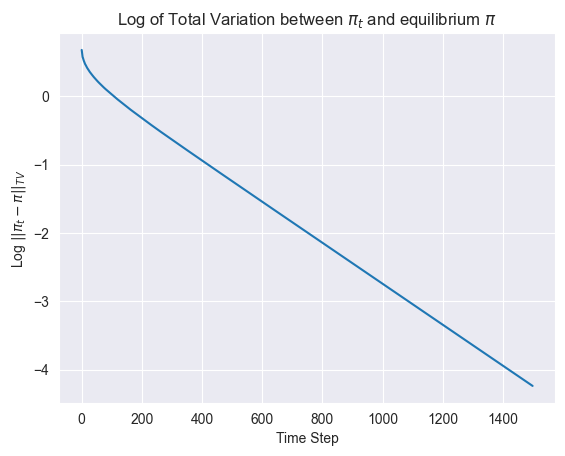

In [6]:
plt.plot(np.log(distance_state)[:1500])
plt.title("Log of Total Variation between $\pi_t$ and equilibrium $\pi$")
plt.ylabel("Log $|| \pi_t - \pi||_{TV}$")
plt.xlabel("Time Step")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(P_star, cmap='viridis', annot=False, cbar=True)
plt.xlabel("Next inventory state")
plt.ylabel("Current inventory state")
plt.title("Optimal Inventory Transition Matrix (P*)")
plt.show()

NameError: name 'inv' is not defined

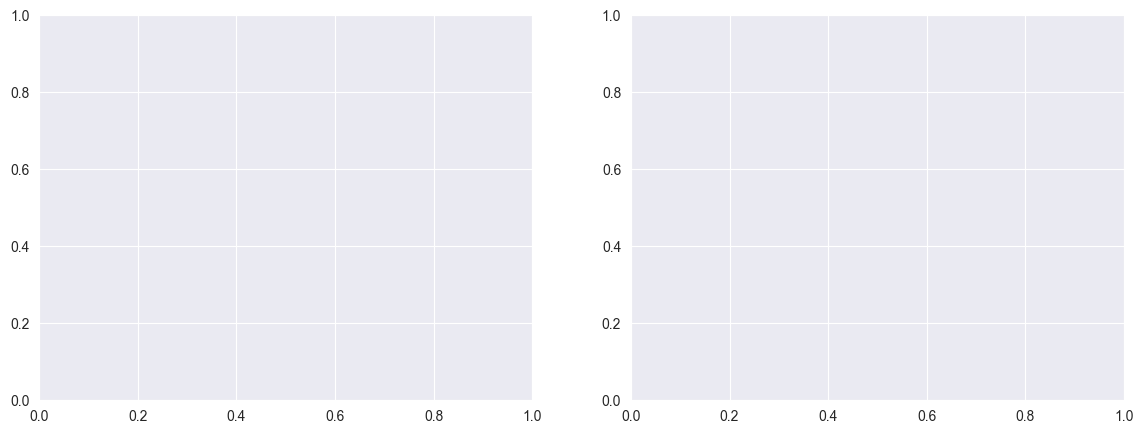

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns

# --- Plot 1: Histogram + Theoretical Distribution ---
ax = axes[0]
ax.hist([inv[:, 1050], inv[:, 1200], inv[:, 1500], inv[:, 1750], inv[:, 2000]],
         bins=21, alpha=0.5, label=['t=1000s', 't=1250s', 't=1500s', 't=1750s', 't=2000s'])
ax.set_xlabel("q")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of $Q_t$ over time t")
ax.legend(loc='upper left')

# Twin y-axis for theoretical distribution
ax2 = ax.twinx()
ax2.plot(np.arange(q_lower, q_upper + 1, 1), pi, '--', label='theoretical distribution', color='blue')
ax2.set_ylabel('Density')
ax2.set_ylim(0, 0.08)
ax2.legend(loc='upper right')

# --- Plot 2: Log of Total Variation Distance ---
axes[1].plot(np.log(distance_state)[:1500])
axes[1].set_title("Log of Total Variation between $\pi_t$ and equilibrium $\pi$")
axes[1].set_ylabel("Log $|| \pi_t - \pi||_{TV}$")
axes[1].set_xlabel("Time (s)")

plt.tight_layout()

#plt.savefig("/Users/galen/Desktop/ergodicity.pdf", format='pdf', bbox_inches='tight')
plt.show()
plt.close()
